# Machine learning - Agrégation de modèles

## TP noté - Master SDDP

Raphaël CARRERE & Jean Florencin LAPITRE

On considère le jeu de données ESCAP.csv tiré des résultats de l’enquête ESCAPAD 2017. Cette enquête est présentée aux appelés (environ 40 000 appelés) à la Journée Défense Citoyenneté (JDC). 
Seule une partie des réponses vous est fournie : elle concerne le tronc commun (qui porte sur la situation personnelle des appelés) et le module B (qui porte sur la consommation de boissons alcoolisées).

La variable à prédire est la variable quantitative Q19A, « Age au premier alcool ».

## 0 - Importation des packages et des données

### Installation des packages

In [ ]:
pip install s3fs

Chargement des packages utilisés

In [38]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import s3fs
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools
from scipy.stats import chi2_contingency
import statsmodels.stats.weightstats as ws
from sklearn.model_selection import train_test_split
import geopandas as gpd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

### Chargement des données

Les données ont été déposées sur S3. Après analyse de l'encodage de la table, on choisit directement de considérer les espaces vides comme des NA. 

In [4]:
MY_BUCKET = "raphcrre"
PATH_ESCAP = f"s3://{MY_BUCKET}/diffusion/projet_apprentissage/ESCAP.csv"

escap = pd.read_csv(PATH_ESCAP, sep=";", decimal=",", na_values=[" ", "  ", ""])
escap


,A01,Q03,Q04,Q04A,Q04B,Q05,Q06A,Q06B,Q08,Q08C,Q09A1,Q09B1,Q10A1,Q10B1,Q19A,B08A,B08B,pm17B
0,10273,1.0,2.0,NaN,NaN,2.0,1.0,2.0,1.0,2.0,1.0,3.0,6.0,8.0,13.0,NaN,NaN,0.429990
1,37216,1.0,1.0,2.0,NaN,1.0,2.0,3.0,1.0,1.0,1.0,1.0,2.0,7.0,14.0,NaN,NaN,0.429990
2,9527,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.0,6.0,11.0,2.0,1.0,0.440840
3,10279,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.0,6.0,14.0,4.0,2.0,0.440840
4,10282,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,6.0,15.0,1.0,1.0,0.440840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13309,6872,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,6.0,17.0,3.0,2.0,2.640086
13310,6891,1.0,1.0,1.0,NaN,1.0,1.0,1.0,2.0,1.0,1.0,1.0,5.0,6.0,16.0,3.0,3.0,2.640086
13311,6878,1.0,1.0,1.0,NaN,1.0,2.0,1.0,1.0,2.0,1.0,2.0,3.0,6.0,15.0,1.0,1.0,2.651554
13312,6907,1.0,1.0,1.0,NaN,2.0,2.0,3.0,1.0,2.0,2.0,1.0,NaN,NaN,16.0,1.0,1.0,2.651554


In [5]:
print("--- Types détectés ---")
print("Q19A  (cible) :", escap["Q19A"].dtype)
print("pm17B (poids) :", escap["pm17B"].dtype)

print("\n--- Aperçu des 5 premières lignes ---")
print(escap[["A01", "Q03", "Q19A", "pm17B"]].head())

--- Types détectés ---
Q19A  (cible) : float64
pm17B (poids) : float64

--- Aperçu des 5 premières lignes ---
     A01  Q03  Q19A    pm17B
0  10273  1.0  13.0  0.42999
1  37216  1.0  14.0  0.42999
2   9527  1.0  11.0  0.44084
3  10279  1.0  14.0  0.44084
4  10282  1.0  15.0  0.44084


### Traitement des données manquantes

In [6]:
escap["Q19A"] = pd.to_numeric(escap["Q19A"], errors="coerce")

def generate_data_summary(data):
    summary_list = []

    for col in data.columns:
        col_series = data[col]
        nb_na = col_series.isna().sum()
        pct_na = (nb_na / len(data)) * 100
        n_unique = col_series.nunique(dropna=False)
        unique_vals = col_series.unique()

        # Distribution / top modalités
        val_counts = col_series.value_counts(dropna=False).head(5).to_dict()

        summary_list.append(
            {
                "Variable": col,
                "Type": str(col_series.dtype),
                "Nb_NA (vrais)": nb_na,
                "%_NA": round(pct_na, 2),
                "Nb_Modalités": n_unique,
                "Valeurs_Uniques": list(unique_vals[:10]),  # 10 premières
                "Top_5_Frequences": val_counts,
            }
        )

    return pd.DataFrame(summary_list)


# Génération du rapport de synthèse
summary_df = generate_data_summary(escap)

# Configuration d'affichage pandas pour tout voir correctement
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

print("=== SUMMARY GÉNÉRAL DES VARIABLES DE LA BASE ESCAP ===")
print(summary_df[["Variable", "Type", "%_NA", "Nb_Modalités", "Top_5_Frequences"]])

=== SUMMARY GÉNÉRAL DES VARIABLES DE LA BASE ESCAP ===
   Variable     Type   %_NA  Nb_Modalités                                                                            Top_5_Frequences
0       A01    int64   0.00         13314                                           {10273: 1, 37216: 1, 9527: 1, 10279: 1, 10282: 1}
1       Q03  float64   0.17             3                                                             {1.0: 6725, 2.0: 6566, nan: 23}
2       Q04  float64  11.89             3                                                           {1.0: 11241, nan: 1583, 2.0: 490}
3      Q04A  float64   4.45             4                                                  {1.0: 11616, 2.0: 952, nan: 593, 3.0: 153}
4      Q04B  float64  95.97             5                                         {nan: 12777, 2.0: 264, 1.0: 139, 4.0: 100, 3.0: 34}
5       Q05  float64   0.30             3                                                             {1.0: 9269, 2.0: 4005, nan: 40}
6      

In [7]:
# Fonction pour afficher la distribution complète d'une variable
def inspect_variable(data, col_name):
    print(f"\n--- Distribution détaillée de : {col_name} ---")
    counts = data[col_name].value_counts(dropna=False).sort_index()
    pct = (
        data[col_name]
        .value_counts(normalize=True, dropna=False)
        .sort_index()
        * 100
    )
    df_res = pd.DataFrame({"Effectif": counts, "Pourcentage (%)": pct.round(2)})
    print(df_res)


# Exemple d'inspection sur les variables clés
for col in ["Q19A", "Q04A", "Q08C", "Q09A1", "Q10A1", "B08A"]:
    inspect_variable(escap, col)


--- Distribution détaillée de : Q19A ---
      Effectif  Pourcentage (%)
Q19A                           
0.0          3             0.02
1.0          5             0.04
2.0          7             0.05
3.0         19             0.14
4.0          7             0.05
5.0         15             0.11
6.0         42             0.32
7.0         54             0.41
8.0        110             0.83
9.0         67             0.50
10.0       410             3.08
11.0       177             1.33
12.0       653             4.90
13.0       982             7.38
14.0      2150            16.15
15.0      3244            24.37
16.0      2331            17.51
17.0       568             4.27
18.0        45             0.34
19.0        25             0.19
20.0         1             0.01
25.0         3             0.02
26.0         2             0.02
32.0         1             0.01
NaN       2393            17.97

--- Distribution détaillée de : Q04A ---
      Effectif  Pourcentage (%)
Q04A                

In [8]:
# Afficher les fréquences des âges extrêmes
print("--- Valeurs inférieures à 10 ans ---")
print(escap[escap["Q19A"] < 10]["Q19A"].value_counts().sort_index())

print("\n--- Valeurs supérieures ou égales à 18 ans ---")
print(escap[escap["Q19A"] >= 18]["Q19A"].value_counts().sort_index())

--- Valeurs inférieures à 10 ans ---
Q19A
0.0      3
1.0      5
2.0      7
3.0     19
4.0      7
5.0     15
6.0     42
7.0     54
8.0    110
9.0     67
Name: count, dtype: int64

--- Valeurs supérieures ou égales à 18 ans ---
Q19A
18.0    45
19.0    25
20.0     1
25.0     3
26.0     2
32.0     1
Name: count, dtype: int64


Les valeurs manquantes sont codées par des espaces vides et non par des NA initialement donc on a chargé directement les données en recodant les NA. La variable cible Q19A contient 17,97% de NA ainsi que des valeurs extrêmes à traiter (impossible de boire son premier verre d'alcool après 25 ans sachant que le questionnaire est donné pendant la JDC qui a lieu pour les citoyens entre 16 et 25 ans). 

In [9]:
# 1. Copie de travail
df_clean = escap.copy()

# 2. Filtrage de la cible sur la plage plausible (5 à 20 ans)
df_clean = df_clean[
    df_clean["Q19A"].notna()
    & (df_clean["Q19A"] >= 5)
    & (df_clean["Q19A"] <= 20)
].copy()

# 3. Filtrage des poids valides
df_clean = df_clean[
    df_clean["pm17B"].notna() & (df_clean["pm17B"] > 0)
].copy()

# 4. Traitement des prédicteurs (passage des NaN en catégorie "Manquant")
cols_predicteurs = [
    c for c in df_clean.columns if c not in ["Q19A", "pm17B", "A01"]
]

for col in cols_predicteurs:
    df_clean[col] = (
        df_clean[col].fillna("Manquant").astype(str).astype("category")
    )

# 5. Calcul des statistiques descriptives de la cible (non pondérées et pondérées)
moyenne_brute = df_clean["Q19A"].mean()
moyenne_pond = np.average(df_clean["Q19A"], weights=df_clean["pm17B"])

print("=== BILAN DU NETTOYAGE ===")
print(f"Nombre d'observations initiales  : {len(escap)}")
print(f"Nombre d'observations conservées : {len(df_clean)}")
print(f"Somme des poids de sondage    : {df_clean['pm17B'].sum():.2f}")
print(f"Moyenne brute de Q19A         : {moyenne_brute:.2f} ans")
print(f"Moyenne pondérée de Q19A      : {moyenne_pond:.2f} ans")

=== BILAN DU NETTOYAGE ===
Nombre d'observations initiales  : 13314
Nombre d'observations conservées : 10874
Somme des poids de sondage    : 10836.42
Moyenne brute de Q19A         : 14.33 ans
Moyenne pondérée de Q19A      : 14.32 ans


La base contient 10 874 observations exploitables avec une somme des poids de sondage cohérente. 

## 1 - Statistique descriptive de la table

### Analyse de la variable d'âge au premier alcool (variable cible)

In [10]:
# Dictionnaire des libellés principaux pour la lisibilité
labels_dict = {
    "Q03": "Sexe",
    "B08A": "Consommation Père Alcool",
    "B08B": "Consommation Mère Alcool",
    "Q04": "Situation Études",
    "Q05": "Redoublement",
    "Q10A1": "PCS Père",
    "Q10B1": "PCS Mère",
}

variables_a_traiter = ["Q19A", "Q03", "B08A", "B08B", "Q04", "Q05", "Q10A1", "Q10B1"]
lignes_tableau = []

# Somme totale des poids pour le calcul des proportions pondérées
somme_poids_totale = df_clean["pm17B"].sum()

for var in variables_a_traiter:
    nom_var = labels_dict.get(var, var)

    # Regroupement par modalité
    for mod, group in df_clean.groupby(var, observed=False):
        n_brut = len(group)
        poids_mod = group["pm17B"].sum()
        prop_pond = (poids_mod / somme_poids_totale) * 100

        lignes_tableau.append(
            {
                "Variable": nom_var,
                "Modalité": str(mod),
                "Effectif brut (N)": n_brut,
                "Proportion pondérée (%)": round(prop_pond, 2),
            }
        )

# Création du DataFrame récapitulatif
df_freq = pd.DataFrame(lignes_tableau)

# Affichage par variable
for var_label in df_freq["Variable"].unique():
    print(f"\n=== Distribution : {var_label} ===")
    sous_table = df_freq[df_freq["Variable"] == var_label][
        ["Modalité", "Effectif brut (N)", "Proportion pondérée (%)"]
    ]
    print(sous_table.to_string(index=False))


=== Distribution : Q19A ===
Modalité  Effectif brut (N)  Proportion pondérée (%)
     5.0                 15                     0.15
     6.0                 42                     0.42
     7.0                 54                     0.51
     8.0                110                     1.07
     9.0                 67                     0.62
    10.0                410                     3.78
    11.0                177                     1.63
    12.0                653                     5.99
    13.0                982                     8.96
    14.0               2150                    19.86
    15.0               3244                    29.93
    16.0               2331                    21.28
    17.0                568                     5.14
    18.0                 45                     0.41
    19.0                 25                     0.24
    20.0                  1                     0.01

=== Distribution : Sexe ===
Modalité  Effectif brut (N)  Proportion p

Ces premiers tableaux nous fournissent déjà un bel aperçu de la base de données. 

Il y a une concentration forte de l'âge au premier verre (Q19A) entre 14 et 16 ans : près de 71 % des jeunes déclarent avoir bu leur premier verre entre 14 et 16 ans (avec un mode à 15 ans représentant 29,9 % de l'échantillon). Les initiations précoces représentents plusde 8 % des répondants (11 ans et moins) et les initiations tardives sont rares (plus de 18 ans : < 1%). Cela reste normal avec une population répondante jeune au moment de la JDC (souvent moins de 18 ans). 

Pour la modélisation cela implique que la distribution est relativement resserrée avec une faible variance. Un modèle qui prédit constamment autour de 14-15 ans aura un faible écart moyen (MAE/RMSE), il faudra donc analyser attentivement les erreurs sur les valeurs extrêmes.

Au niveau de la consommation des parents (B08A & B08B), on retrouve un biais paternel : 16,55 % consomment de l'alcool presque chaque jour (modalité 5) et 24,54 % au moins une fois par semaine (modalité 4). Au total, plus de 41 % des pères consomment régulièrement à la maison. En revanche, la consommation quotidienne de la mère est deux fois plus faible (8,15%) et 24,21% ne boivent jamais. Il y a beaucoup de données manquantes (8%), expliquées probablement par les foyers monoparentaux.


84,76 % des jeunes suivent encore des études et 28,25% déclarent avoir déjà redoublé. 


In [20]:
def weighted_quantile(values, quantiles, sample_weight=None):
    """Calcule des quantiles pondérés précis."""
    values = np.array(values)
    quantiles = np.array(quantiles)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    sample_weight = np.array(sample_weight)
    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]
    weighted_quantiles = np.cumsum(sample_weight) - 0.5 * sample_weight
    weighted_quantiles /= np.sum(sample_weight)
    return np.interp(quantiles, weighted_quantiles, values)


# Calculs des indicateurs pondérés
q25, q50, q75 = weighted_quantile(
    df_clean["Q19A"], [0.25, 0.50, 0.75], sample_weight=df_clean["pm17B"]
)
descr = ws.DescrStatsW(df_clean["Q19A"], weights=df_clean["pm17B"])

print("=== BASSIN DESCRIPTIF DE LA CIBLE Q19A (PONDÉRÉ) ===")
print(f"Moyenne pondérée    : {descr.mean:.2f} ans")
print(f"Écart-type pondéré  : {descr.std:.2f} ans")
print(
    f"Médiane pondérée    : {q50:.2f} ans"
)  # Crucial : si moyenne < médiane -> asymétrie à gauche
print(f"Intervalle Q1 - Q3  : [{q25:.1f} ans ; {q75:.1f} ans]")
print(f"Écart interquartile : {q75 - q25:.1f} ans")

=== BASSIN DESCRIPTIF DE LA CIBLE Q19A (PONDÉRÉ) ===
Moyenne pondérée    : 14.32 ans
Écart-type pondéré  : 1.97 ans
Médiane pondérée    : 15.00 ans
Intervalle Q1 - Q3  : [14.0 ans ; 16.0 ans]
Écart interquartile : 2.0 ans


### Analyse bivariée

In [11]:
bivariate_results = []

for col in cols_predicteurs:
    # 1. Moyennes pondérées de Q19A pour chaque modalité du prédicteur
    means_by_cat = df_clean.groupby(col, observed=False).apply(
        lambda g: (
            np.average(g["Q19A"], weights=g["pm17B"]) if len(g) > 0 else np.nan
        )
    )

    # 2. Test statistique de Kruskal-Wallis
    groups = [
        group["Q19A"].values
        for _, group in df_clean.groupby(col, observed=False)
        if len(group) > 0
    ]
    stat, p_val = stats.kruskal(*groups)

    bivariate_results.append(
        {
            "Variable": col,
            "p-value": f"{p_val:.2e}",
            "Significatif (<0.05)": "Oui" if p_val < 0.05 else "Non",
            "Moyennes par catégorie": dict(means_by_cat.round(2)),
        }
    )

df_biv = pd.DataFrame(bivariate_results)

print("=== STATISTIQUES BIVARIÉES : LIEN AVEC L'ÂGE AU 1ER VERRE ===")
print(df_biv[["Variable", "p-value", "Significatif (<0.05)"]])

=== STATISTIQUES BIVARIÉES : LIEN AVEC L'ÂGE AU 1ER VERRE ===
   Variable   p-value Significatif (<0.05)
0       Q03  2.57e-29                  Oui
1       Q04  2.72e-05                  Oui
2      Q04A  5.26e-02                  Non
3      Q04B  1.56e-02                  Oui
4       Q05  9.01e-22                  Oui
5      Q06A  1.95e-07                  Oui
6      Q06B  3.73e-07                  Oui
7       Q08  2.21e-03                  Oui
8      Q08C  4.71e-01                  Non
9     Q09A1  1.10e-03                  Oui
10    Q09B1  8.11e-06                  Oui
11    Q10A1  1.39e-30                  Oui
12    Q10B1  6.07e-28                  Oui
13     B08A  2.63e-47                  Oui
14     B08B  1.01e-48                  Oui


Quasiment toutes les variables sont significativement liées à l'âge au premier verre par le test de Kruskal-Wallis (p <0.05). Les p-values sur les variables de consommation des parents (B08A et B08B) sont très significatives. Le sexe (Q03) et la CPS des parents (Q10A1 et Q10B1) sont également très significatives. En revanche, deux variables ne sont pas significatives : Q04A qui correspond à la situation scolaire et Q08C qui correspond à la vie des parents. Ces tests de Kruskal-Wallis ne s'appuient pas sur les pondérations. C'est pourquoi nous effetuons également une ANOVA pondérée. 

In [18]:
results_anova = []

for col in cols_predicteurs:
    # Modèle linéaire avec poids de sondage
    model = smf.wls(f"Q19A ~ C({col})", data=df_clean, weights=df_clean["pm17B"]).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_val = anova_table.loc[f"C({col})", "PR(>F)"]
    f_stat = anova_table.loc[f"C({col})", "F"]

    results_anova.append(
        {
            "Variable": col,
            "F-Stat": round(f_stat, 2),
            "p-value (ANOVA pondérée)": f"{p_val:.2e}",
            "Significatif": "Oui" if p_val < 0.05 else "Non",
        }
    )

df_anova = pd.DataFrame(results_anova).sort_values(by="F-Stat", ascending=False)
print("=== TESTS D'EFFET GLOBAL PONDÉRÉS (ANOVA WLS) ===")
print(df_anova.to_string(index=False))

=== TESTS D'EFFET GLOBAL PONDÉRÉS (ANOVA WLS) ===
Variable  F-Stat p-value (ANOVA pondérée) Significatif
     Q03   72.56                 4.96e-32          Oui
    B08A   41.81                 8.57e-43          Oui
    B08B   39.43                 2.70e-40          Oui
     Q05   35.73                 3.43e-16          Oui
   Q10A1   16.76                 9.59e-28          Oui
   Q10B1   13.83                 2.23e-22          Oui
     Q04   13.07                 2.14e-06          Oui
    Q06B    9.05                 5.59e-06          Oui
    Q06A    8.87                 7.24e-06          Oui
    Q04A    4.72                 2.72e-03          Oui
   Q09B1    3.23                 1.98e-03          Oui
     Q08    3.18                 7.16e-03          Oui
    Q04B    2.83                 2.34e-02          Oui
   Q09A1    2.03                 4.79e-02          Oui
    Q08C    0.75                 5.89e-01          Non


L'analyse de variance à moindres carrés pondérés (WLS) valide l'influence de la quasi-totalité des prédicteurs socio-démographiques et familiaux sur l'âge de première consommation d'alcool (Q19A).

Sur les 15 prédicteurs testés avec la pondération, 14 variables présentent un effet global significatif au seuil alpha = 5 % (p < 0,05).   Seule la variable Q08C ("Vie des parents", F = 0,75, p = 0,589) n'est pas significative.

La statistique F de Snedecor mesure l'intensité de la variance inter-groupes expliquée par rapport à la variance intra-groupe residuelle. 


On peut voir que le Sexe est le facteur explicatif le plus discriminant (F > 30). La consommation des parents constitue également un prédicteur important de la variable cible (F > 30). Vient ensuite le parcours scolaire avec la variable de redoublement. Il y a aussi les variables d'origine sociale avec les PCS des parents qui influencent significativement l'âge au premier alcool. Ces variables ont une valeur de F entre 10 et 20. 

Les facteurs suivants ont un effet plus modéré mais bien présent (2 < F < 10): situations scolaire et professionnelle, difficultés scolaires, situation d'activité des parents. 

Le statut marital des parents n'est pas significatif. 

Ces résultats impliquent que la variable de vie des parents peut être écartée (ou laissée aux arbres qui l'écarteront naturellement). L'ANOVA montre que la question Q04 absorbe les questions Q04A et Q04B. Enfin, on s'attend à ce que le Sexe, la consommation des parents et le redoublement soient des variables importantes dans nos modèles. 

In [12]:
def afficher_detail_variable(col_name):
    row = df_biv[df_biv["Variable"] == col_name].iloc[0]
    print(f"\n--- Détail pour {col_name} ---")
    print(f"p-value : {row['p-value']}")
    print("Âge moyen pondéré par catégorie :")
    for cat, val in row["Moyennes par catégorie"].items():
        print(f"  Modalité {cat} : {val} ans")


# Exemple sur le Sexe (Q03) et la consommation du Père (B08A)
afficher_detail_variable("Q03")
afficher_detail_variable("B08A")
afficher_detail_variable("B08B")


--- Détail pour Q03 ---
p-value : 2.57e-29
Âge moyen pondéré par catégorie :
  Modalité 1.0 : 14.1 ans
  Modalité 2.0 : 14.55 ans
  Modalité Manquant : 13.93 ans

--- Détail pour B08A ---
p-value : 2.63e-47
Âge moyen pondéré par catégorie :
  Modalité 1.0 : 14.74 ans
  Modalité 2.0 : 14.61 ans
  Modalité 3.0 : 14.34 ans
  Modalité 4.0 : 14.16 ans
  Modalité 5.0 : 13.94 ans
  Modalité Manquant : 14.19 ans

--- Détail pour B08B ---
p-value : 1.01e-48
Âge moyen pondéré par catégorie :
  Modalité 1.0 : 14.68 ans
  Modalité 2.0 : 14.45 ans
  Modalité 3.0 : 14.26 ans
  Modalité 4.0 : 14.08 ans
  Modalité 5.0 : 13.83 ans
  Modalité Manquant : 14.13 ans


On remarque une différence dans l'âge moyen pondéré au premier verre entre les sexes avec les hommes qui boivent en moyenne plus tôt que les femmes (14,09 ans contre 14,54 ans). Le fait que le père (B08A) et/ou la mère (B08B) consomment de l'alcool régulièrement diminue l'âge du premier verre d'alcool (0.8 ans de différence en moyenne pondérée entre une consommation quotidienne et une consommation nulle des parents. 

Boxplots de l'âge au premier alcool en fonction du sexe et de la consommation des parents

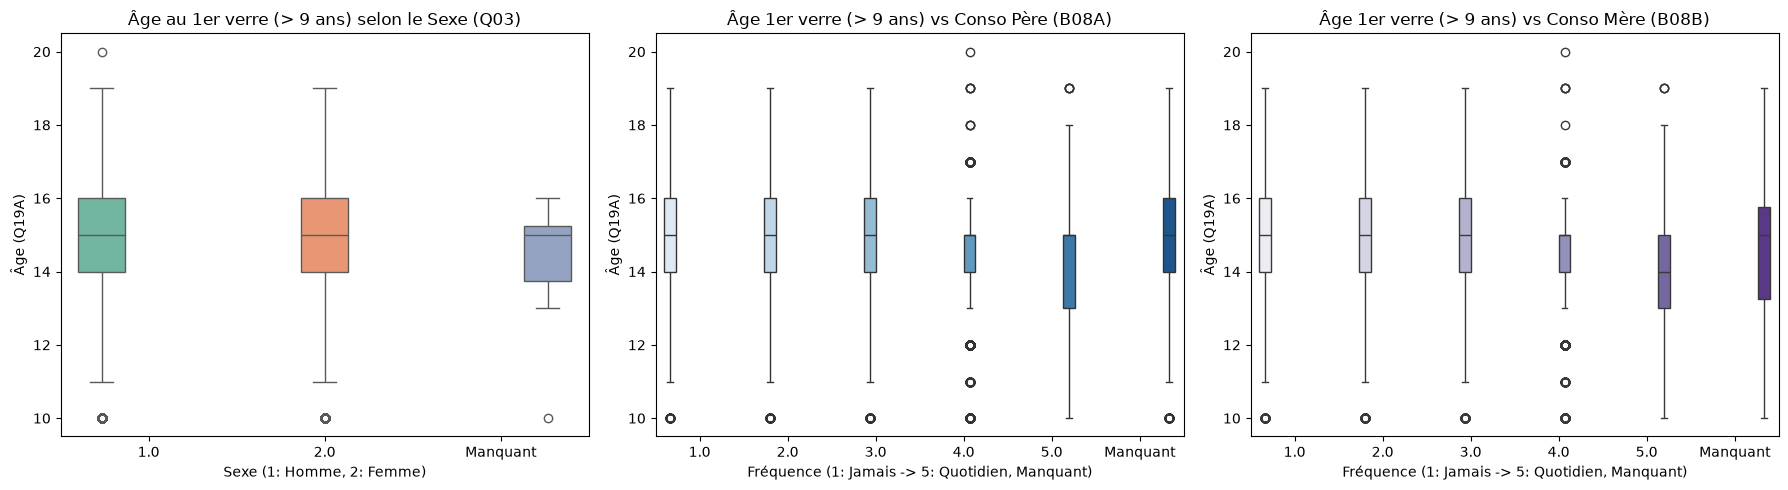

In [13]:
# Création du sous-ensemble filtré (âge > 9 ans) pour la lisibilité des boxplots
df_filtered = df_clean[df_clean["Q19A"] > 9]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Âge 1er verre vs Sexe (Q03)
sns.boxplot(
    data=df_filtered,
    x="Q03",
    y="Q19A",
    ax=axes[0],
    palette="Set2",
    hue="Q03",
    legend=False,
)
axes[0].set_title("Âge au 1er verre (> 9 ans) selon le Sexe (Q03)")
axes[0].set_xlabel("Sexe (1: Homme, 2: Femme)")
axes[0].set_ylabel("Âge (Q19A)")

# 2. Âge 1er verre vs Conso Père (B08A)
sns.boxplot(
    data=df_filtered,
    x="B08A",
    y="Q19A",
    ax=axes[1],
    palette="Blues",
    hue="B08A",
    legend=False,
)
axes[1].set_title("Âge 1er verre (> 9 ans) vs Conso Père (B08A)")
axes[1].set_xlabel("Fréquence (1: Jamais -> 5: Quotidien, Manquant)")
axes[1].set_ylabel("Âge (Q19A)")

# 3. Âge 1er verre vs Conso Mère (B08B)
sns.boxplot(
    data=df_filtered,
    x="B08B",
    y="Q19A",
    ax=axes[2],
    palette="Purples",
    hue="B08B",
    legend=False,
)
axes[2].set_title("Âge 1er verre (> 9 ans) vs Conso Mère (B08B)")
axes[2].set_xlabel("Fréquence (1: Jamais -> 5: Quotidien, Manquant)")
axes[2].set_ylabel("Âge (Q19A)")

plt.tight_layout()
plt.show()

Graphique de l'âge au premier alcool selon le sexe

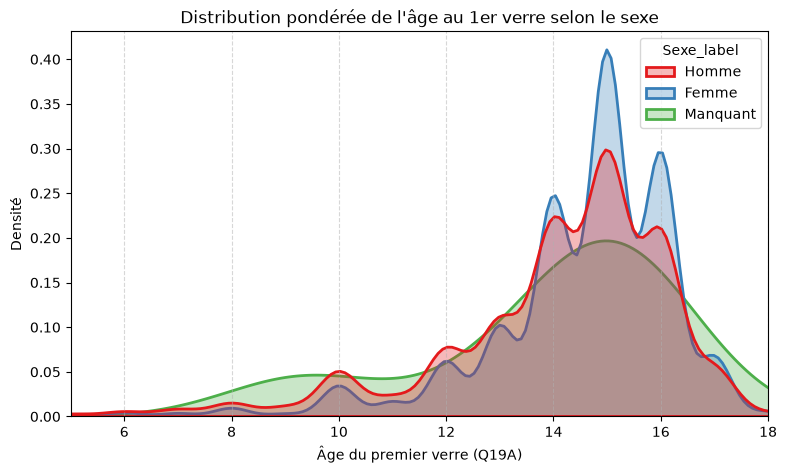

In [14]:
# Dictionnaire pour un affichage lisible de Q03
sexe_map = {"1.0": "Homme", "2.0": "Femme", "1": "Homme", "2": "Femme"}
df_clean["Sexe_label"] = df_clean["Q03"].astype(str).map(sexe_map).fillna(df_clean["Q03"])

plt.figure(figsize=(9, 5))
sns.kdeplot(
    data=df_clean,
    x="Q19A",
    hue="Sexe_label",
    weights="pm17B",  # Prise en compte du poids de sondage
    common_norm=False,
    fill=True,
    alpha=0.3,
    linewidth=2,
    palette="Set1",
)

plt.title("Distribution pondérée de l'âge au 1er verre selon le sexe")
plt.xlabel("Âge du premier verre (Q19A)")
plt.ylabel("Densité")
plt.xlim(5, 18)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

### Analyse des prédicteurs

In [15]:
def cramers_v(var1, var2):
    """Calcule le V de Cramér entre deux variables catégorielles."""
    contingency_tab = pd.crosstab(var1, var2)
    chi2 = chi2_contingency(contingency_tab)[0]
    n = contingency_tab.sum().sum()
    r, k = contingency_tab.shape
    if min(r - 1, k - 1) == 0:
        return 0.0
    return np.sqrt(chi2 / (n * min(k - 1, r - 1)))


# Calcul croisé sur l'ensemble des prédicteurs
cramer_results = []

for col1, col2 in itertools.combinations(cols_predicteurs, 2):
    contingency_tab = pd.crosstab(df_clean[col1], df_clean[col2])
    chi2, p_val, dof, _ = chi2_contingency(contingency_tab)
    v = cramers_v(df_clean[col1], df_clean[col2])

    cramer_results.append(
        {
            "Variable 1": col1,
            "Variable 2": col2,
            "Chi2": round(chi2, 2),
            "p-value": f"{p_val:.2e}",
            "V de Cramér": round(v, 3),
        }
    )

df_cramer = pd.DataFrame(cramer_results).sort_values(
    by="V de Cramér", ascending=False
)

print("=== TOP 10 DES LIAISONS LES PLUS FORTES ENTRE PRÉDICTEURS ===")
print(df_cramer.head(10).to_string(index=False))

=== TOP 10 DES LIAISONS LES PLUS FORTES ENTRE PRÉDICTEURS ===
Variable 1 Variable 2     Chi2  p-value  V de Cramér
       Q04       Q04A  9109.92 0.00e+00        0.647
       Q04       Q04B  8828.30 0.00e+00        0.637
      Q04A       Q04B  9319.43 0.00e+00        0.534
      B08A       B08B 14749.68 0.00e+00        0.521
     Q09A1      Q10A1 13269.46 0.00e+00        0.418
     Q09B1      Q10B1 11776.66 0.00e+00        0.393
      Q06A       Q06B  4125.61 0.00e+00        0.356
     Q10A1      Q10B1  8558.01 0.00e+00        0.296
      Q08C      Q09A1  4272.80 0.00e+00        0.280
      Q08C      Q10A1  3006.69 0.00e+00        0.235


La situation scolaire et le parcours professionnel sont très corrélés, de même que la consommation de chacun des parents ou encore la situation professionnel et la PCS des deux parents. Les difficultés scolaires se recoupent aussi fortement. 

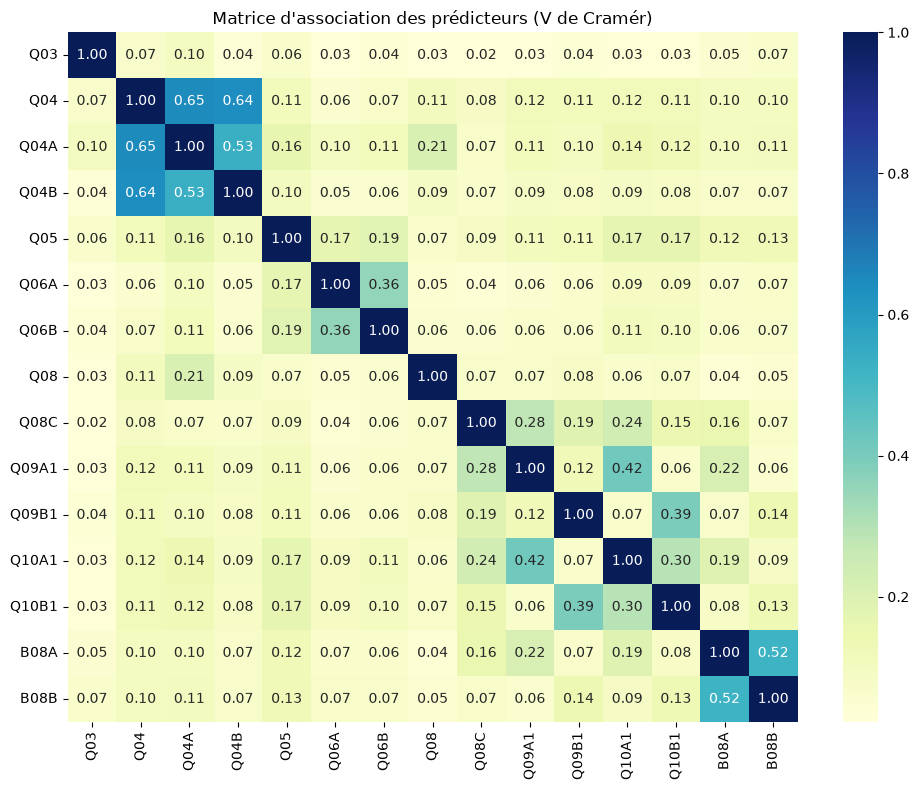

In [16]:
# Construction de la matrice carrée des V de Cramér
matrix_v = pd.DataFrame(
    index=cols_predicteurs, columns=cols_predicteurs, dtype=float
)

for c1 in cols_predicteurs:
    for c2 in cols_predicteurs:
        if c1 == c2:
            matrix_v.loc[c1, c2] = 1.0
        else:
            matrix_v.loc[c1, c2] = cramers_v(df_clean[c1], df_clean[c2])

plt.figure(figsize=(10, 8))
sns.heatmap(matrix_v, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Matrice d'association des prédicteurs (V de Cramér)")
plt.tight_layout()
plt.show()

## 2 - Modélisation et agrégation

Préparation des modélisations 

In [22]:
# 1. Sélection des prédicteurs (on retire Q19A, pm17B, A01 et la colonne temporaire Sexe_label)
X_cols = [
    col
    for col in df_clean.columns
    if col not in ["Q19A", "pm17B", "A01", "Sexe_label", "Q08C"]
]  # On écarte Q08C car non significative

X_raw = df_clean[X_cols]
y = df_clean["Q19A"]
weights = df_clean["pm17B"]

# 2. Dummification (One-Hot Encoding)
X_encoded = pd.get_dummies(X_raw, drop_first=True, dtype=int)

# 3. Découpage Train / Test (80% / 20%)
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_encoded, y, weights, test_size=0.20, random_state=42
)

print("=== BILAN DE LA PRÉPARATION DES DONNÉES ===")
print(
    f"Nombre d'observations d'entraînement (Train) : {X_train.shape[0]} (poids total : {w_train.sum():.2f})"
)
print(
    f"Nombre d'observations de test (Test)         : {X_test.shape[0]} (poids total : {w_test.sum():.2f})"
)
print(f"Nombre total de variables encodées (p)       : {X_train.shape[1]}")

=== BILAN DE LA PRÉPARATION DES DONNÉES ===
Nombre d'observations d'entraînement (Train) : 8699 (poids total : 8666.54)
Nombre d'observations de test (Test)         : 2175 (poids total : 2169.88)
Nombre total de variables encodées (p)       : 66


In [32]:
# Dictionnaire global pour stocker les résultats et les prédictions
comparatif_modeles = {}
predictions_test = {}


def calculer_indicateurs(
    model, X_tr, y_tr, w_tr, X_te, y_te, w_te, nom_modele
):
    """Calcule et affiche les indicateurs statistiques d'un modèle (Train vs Test)."""
    # Prédictions
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    # Sauvegarde des prédictions test pour le Stacking ultérieur
    predictions_test[nom_modele] = y_pred_te

    # Calculs des métriques pondérées - Train
    rmse_tr = np.sqrt(
        mean_squared_error(y_tr, y_pred_tr, sample_weight=w_tr)
    )
    mae_tr = mean_absolute_error(y_tr, y_pred_tr, sample_weight=w_tr)
    r2_tr = r2_score(y_tr, y_pred_tr, sample_weight=w_tr)

    # Calculs des métriques pondérées - Test
    rmse_te = np.sqrt(
        mean_squared_error(y_te, y_pred_te, sample_weight=w_te)
    )
    mae_te = mean_absolute_error(y_te, y_pred_te, sample_weight=w_te)
    r2_te = r2_score(y_te, y_pred_te, sample_weight=w_te)

    # Stockage
    res = {
        "Modèle": nom_modele,
        "RMSE Train": round(rmse_tr, 4),
        "RMSE Test": round(rmse_te, 4),
        "Écart RMSE (Overfit)": round(rmse_te - rmse_tr, 4),
        "MAE Test": round(mae_te, 4),
        "R2 Test (%)": round(r2_te * 100, 2),
    }

    comparatif_modeles[nom_modele] = res

    print(f"=== INDICATEURS : {nom_modele.upper()} ===")
    print(
        f"  • RMSE Train : {rmse_tr:.4f} ans | RMSE Test : {rmse_te:.4f} ans"
    )
    print(f"  • Écart Overfitting (Test - Train) : {rmse_te - rmse_tr:.4f} ans")
    print(f"  • MAE Test  : {mae_te:.4f} ans")
    print(f"  • R² Test   : {r2_te * 100:.2f} % de variance expliquée\n")

    return res

### Modèle de référence - Régression Ridge pondérée

Avant de tester des forêts d'arbres, nous mettons en palce un modèle linéaire régularisé simple pour savoir si les algorithmes d'ensemble apportent un vrai gain.

In [33]:
# 1. Instanciation et entraînement
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train, sample_weight=w_train)

# 2. Calcul et affichage des indicateurs
res_ridge = calculer_indicateurs(
    ridge_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "1. Baseline (Ridge)",
)

=== INDICATEURS : 1. BASELINE (RIDGE) ===
  • RMSE Train : 1.8927 ans | RMSE Test : 2.0048 ans
  • Écart Overfitting (Test - Train) : 0.1120 ans
  • MAE Test  : 1.4468 ans
  • R² Test   : 3.59 % de variance expliquée



### Modèle de Bagging (Arbres)

Tirage bootstrap d'individus avec arbres complets sans sélection aléatoire de variables à chaque nœud.

In [34]:
# 1. Instanciation et entraînement
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
bagging_model.fit(X_train, y_train, sample_weight=w_train)

# 2. Calcul et affichage des indicateurs
res_bagging = calculer_indicateurs(
    bagging_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "2. Bagging",
)

=== INDICATEURS : 2. BAGGING ===
  • RMSE Train : 1.7133 ans | RMSE Test : 2.0279 ans
  • Écart Overfitting (Test - Train) : 0.3146 ans
  • MAE Test  : 1.4644 ans
  • R² Test   : 1.35 % de variance expliquée



### Modèle de Random Forest

Sélection aléatoire d'un sous-ensemble de variables à chaque nœud d'arbre.

In [35]:
# 1. Instanciation et entraînement
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    max_features="sqrt",  # Clé de la RF : sous-ensemble aléatoire de variables
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train, sample_weight=w_train)

# 2. Calcul et affichage des indicateurs
res_rf = calculer_indicateurs(
    rf_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "3. Random Forest",
)

=== INDICATEURS : 3. RANDOM FOREST ===
  • RMSE Train : 1.8030 ans | RMSE Test : 2.0131 ans
  • Écart Overfitting (Test - Train) : 0.2101 ans
  • MAE Test  : 1.4527 ans
  • R² Test   : 2.79 % de variance expliquée



### Modèle de Gradient boosting

Le Boosting construit des arbres séquentiellement pour corriger les erreurs des arbres précédents. 

In [37]:
# 1. Instanciation et entraînement
gb_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
)
gb_model.fit(X_train, y_train, sample_weight=w_train)

# 2. Calcul et affichage des indicateurs
res_gb = calculer_indicateurs(
    gb_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "4. Gradient Boosting",
)

=== INDICATEURS : 4. GRADIENT BOOSTING ===
  • RMSE Train : 1.8335 ans | RMSE Test : 2.0169 ans
  • Écart Overfitting (Test - Train) : 0.1833 ans
  • MAE Test  : 1.4552 ans
  • R² Test   : 2.42 % de variance expliquée



### Modèle de stacking

Le Stacking combine les prédictions des modèles précédents (Bagging, RF, Boosting) en utilisant un régresseur Ridge pour trouver la meilleure pondération globale. 

In [39]:
# 1. Définition des estimateurs de base
estimators = [
    (
        "bagging",
        BaggingRegressor(
            estimator=DecisionTreeRegressor(max_depth=10, random_state=42),
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "rf",
        RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "gb",
        GradientBoostingRegressor(
            n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42
        ),
    ),
]

# 2. Instanciation du Stacking avec un méta-modèle Ridge
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1,
)
stacking_model.fit(X_train, y_train, sample_weight=w_train)

# 3. Calcul et affichage des indicateurs
res_stacking = calculer_indicateurs(
    stacking_model,
    X_train,
    y_train,
    w_train,
    X_test,
    y_test,
    w_test,
    "5. Stacking (Méta-Modèle)",
)

=== INDICATEURS : 5. STACKING (MÉTA-MODÈLE) ===
  • RMSE Train : 1.7937 ans | RMSE Test : 2.0135 ans
  • Écart Overfitting (Test - Train) : 0.2198 ans
  • MAE Test  : 1.4534 ans
  • R² Test   : 2.75 % de variance expliquée



## 3 - Evaluations et comparaisons des modèles

### Comparaison des performances à l'aide du jeu de test

## 4 - Conclusion